In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_index = pd.read_csv("logRetBenchETF.csv", parse_dates=["date"], index_col=["date"])
df_index

,asamid,asam,agas,ayar,close_overal
date,,,,,
2021-02-15,0.000605,-0.002219,-0.010672,-0.019459,-0.005632
2021-02-16,0.000086,-0.010369,-0.015162,0.013328,-0.009104
2021-02-17,0.000518,0.004690,0.002533,-0.006338,-0.005994
2021-02-20,0.001035,-0.005364,-0.008755,-0.034298,-0.004562
2021-02-21,0.000431,-0.011069,-0.025157,-0.021401,-0.008229
...,...,...,...,...,...
2025-03-18,0.022160,0.000870,-0.028589,0.070726,-0.012468
2025-03-25,0.001085,0.001797,0.029301,-0.015974,0.011238
2025-03-26,0.014114,0.003794,0.015905,0.034820,0.009288


In [3]:
df_highRisk = pd.read_csv("dailyReturn_highRisk.csv", parse_dates=["Date"], index_col=["Date"])
df_lowRisk = pd.read_csv("dailyReturn_lowRisk.csv", parse_dates=["Date"], index_col=["Date"])
df_normalRisk = pd.read_csv("dailyReturn_normalRisk.csv", parse_dates=["Date"], index_col=["Date"])

In [4]:
df_highRisk.drop(columns=["Unnamed: 0"], inplace=True)
df_lowRisk.drop(columns=["Unnamed: 0"], inplace=True)
df_normalRisk.drop(columns=["Unnamed: 0"], inplace=True)

In [5]:
# Rename 'Return' column in each DataFrame
df_highRisk = df_highRisk.rename(columns={"Return": "highRisk"})
df_lowRisk = df_lowRisk.rename(columns={"Return": "lowRisk"})
df_normalRisk = df_normalRisk.rename(columns={"Return": "normalRisk"})

df_index = df_index.rename(columns={
    "close_overal": "close_overal",
    "close_overal30": "close_overal30",
    "close_equalW": "close_equalW"
})

# Standardize index name
df_index.index.name = "Date"

# Merge on common dates
df_merged = df_highRisk.join([
    df_lowRisk,
    df_normalRisk,
    df_index
], how='inner')


In [6]:
df_merged

,highRisk,lowRisk,normalRisk,asamid,asam,agas,ayar,close_overal
Date,,,,,,,,
2022-02-28,0.001993,0.005047,0.005375,0.000634,0.001664,0.004611,0.003912,0.001988
2022-03-02,0.002000,0.001854,0.001771,0.000985,-0.001937,0.000710,0.008937,-0.000541
2022-03-05,0.000488,-0.002000,-0.002074,0.001686,-0.003451,0.016129,-0.016407,0.013695
2022-03-06,0.002692,0.004556,0.004451,0.000562,0.004297,0.034779,-0.006612,0.018156
2022-03-07,0.004764,0.005964,0.005857,0.000561,0.004796,0.016555,0.015316,0.015238
...,...,...,...,...,...,...,...,...
2025-03-17,0.034195,0.010471,0.012032,0.011039,-0.002757,-0.005771,0.058614,-0.003482
2025-03-18,0.040219,0.013166,0.012650,0.022160,0.000870,-0.028589,0.070726,-0.012468
2025-03-25,-0.004562,0.003153,0.003078,0.001085,0.001797,0.029301,-0.015974,0.011238


In [7]:
#df_merged.to_csv("logRetOf_portfolio_bechmarks.csv")

In [8]:
df_merged.describe()

,highRisk,lowRisk,normalRisk,asamid,asam,agas,ayar,close_overal
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,0.002014,0.001396,0.001559,0.001252,0.001352,0.001291,0.002841,0.001062
std,0.012699,0.005133,0.005827,0.003717,0.009813,0.015845,0.023217,0.011188
min,-0.072514,-0.029929,-0.027453,-0.019016,-0.043127,-0.067570,-0.103168,-0.052913
25%,-0.002805,-0.001063,-0.001121,0.000584,-0.003423,-0.007463,-0.007731,-0.004664
50%,0.001362,0.001204,0.001222,0.000690,0.000665,0.000715,0.001747,0.000444
75%,0.007310,0.003701,0.003888,0.001352,0.005869,0.009303,0.014302,0.006096
max,0.075112,0.029135,0.033161,0.045202,0.048719,0.084407,0.093608,0.048422


In [9]:
# Your log return DataFrame is already prepared as df_merged
# Columns: ['highRisk', 'lowRisk', 'normalRisk', 'close_overal', 'close_overal30', 'close_equalW']

# Use the log returns directly
returns = df_merged.copy().dropna()

# Calculate performance metrics
metrics = pd.DataFrame(index=returns.columns)
metrics['Mean Daily Log Return'] = returns.mean()
metrics['Standard Deviation'] = returns.std()
metrics['Sharpe Ratio'] = metrics['Mean Daily Log Return'] / metrics['Standard Deviation']
metrics['Cumulative Return %'] = (np.exp(returns.sum()) - 1)*100  # Convert log return to actual return

metrics

,Mean Daily Log Return,Standard Deviation,Sharpe Ratio,Cumulative Return %
highRisk,0.002014,0.012699,0.158614,335.079979
lowRisk,0.001396,0.005133,0.272008,177.108570
normalRisk,0.001559,0.005827,0.267579,212.085671
asamid,0.001252,0.003717,0.336683,149.345195
asam,0.001352,0.009813,0.137755,168.258423
agas,0.001291,0.015845,0.081488,156.648541
ayar,0.002841,0.023217,0.122355,695.445362
close_overal,0.001062,0.011188,0.094945,117.152997


In [10]:
returns

,highRisk,lowRisk,normalRisk,asamid,asam,agas,ayar,close_overal
Date,,,,,,,,
2022-02-28,0.001993,0.005047,0.005375,0.000634,0.001664,0.004611,0.003912,0.001988
2022-03-02,0.002000,0.001854,0.001771,0.000985,-0.001937,0.000710,0.008937,-0.000541
2022-03-05,0.000488,-0.002000,-0.002074,0.001686,-0.003451,0.016129,-0.016407,0.013695
2022-03-06,0.002692,0.004556,0.004451,0.000562,0.004297,0.034779,-0.006612,0.018156
2022-03-07,0.004764,0.005964,0.005857,0.000561,0.004796,0.016555,0.015316,0.015238
...,...,...,...,...,...,...,...,...
2025-03-17,0.034195,0.010471,0.012032,0.011039,-0.002757,-0.005771,0.058614,-0.003482
2025-03-18,0.040219,0.013166,0.012650,0.022160,0.000870,-0.028589,0.070726,-0.012468
2025-03-25,-0.004562,0.003153,0.003078,0.001085,0.001797,0.029301,-0.015974,0.011238


In [11]:
# Cumulative Growth (from log returns)
cumulative_growth = np.exp(returns.cumsum())
cumulative_growth

,highRisk,lowRisk,normalRisk,asamid,asam,agas,ayar,close_overal
Date,,,,,,,,
2022-02-28,1.001995,1.005059,1.005389,1.000634,1.001665,1.004621,1.003920,1.001990
2022-03-02,1.004002,1.006925,1.007171,1.001620,0.999726,1.005335,1.012932,1.001448
2022-03-05,1.004492,1.004912,1.005084,1.003310,0.996282,1.021681,0.996449,1.015256
2022-03-06,1.007200,1.009501,1.009568,1.003874,1.000572,1.057839,0.989882,1.033858
2022-03-07,1.012010,1.015539,1.015499,1.004437,1.005382,1.075498,1.005159,1.049732
...,...,...,...,...,...,...,...,...
2025-03-17,3.954890,2.669643,3.005981,2.345429,2.641913,2.528583,6.835413,2.144990
2025-03-18,4.117192,2.705023,3.044248,2.397983,2.644212,2.457316,7.336359,2.118412
2025-03-25,4.098454,2.713566,3.053632,2.400586,2.648969,2.530384,7.220099,2.142353


In [12]:
cumulative_growth.columns

Index(['highRisk', 'lowRisk', 'normalRisk', 'asamid', 'asam', 'agas', 'ayar',
       'close_overal'],
      dtype='object')

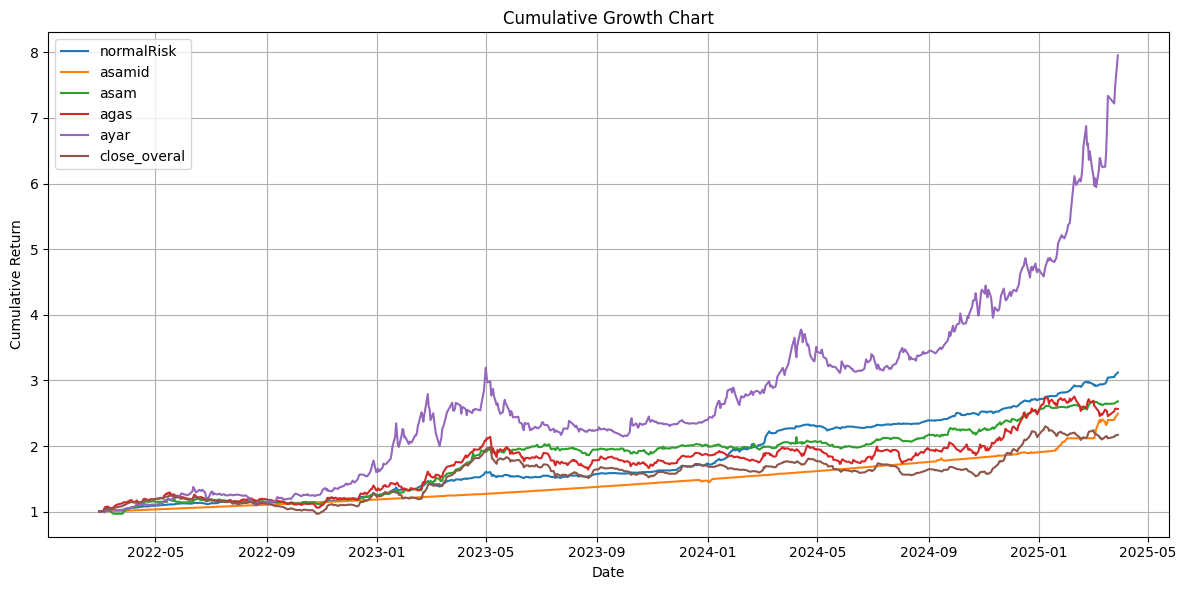

In [13]:
plt.figure(figsize=(12, 6))
columns = ['normalRisk','asamid', 'asam', 'agas', 'ayar', 'close_overal']
for col in columns:
    plt.plot(cumulative_growth.index, cumulative_growth[col], label=col)
plt.title('Cumulative Growth Chart')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Cum_normalRisk")
plt.show()

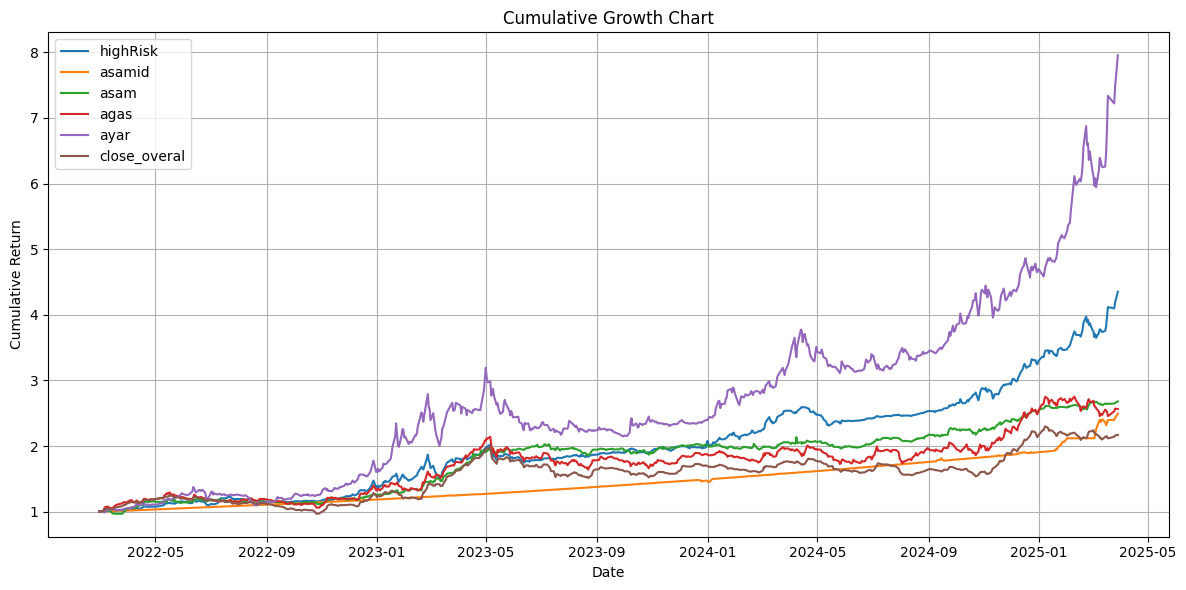

In [14]:
plt.figure(figsize=(12, 6))
columns = ['highRisk','asamid', 'asam', 'agas', 'ayar', 'close_overal']
for col in columns:
    plt.plot(cumulative_growth.index, cumulative_growth[col], label=col)
plt.title('Cumulative Growth Chart')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Cum_highRisk")
plt.show()

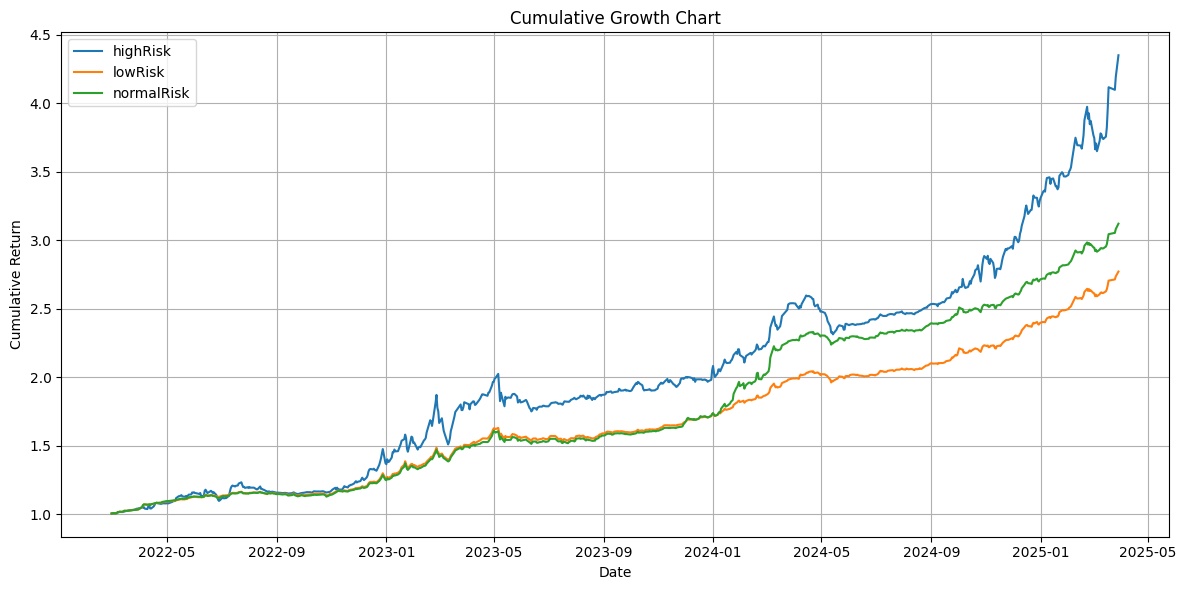

In [15]:
plt.figure(figsize=(12, 6))
columns = ['highRisk', 'lowRisk', 'normalRisk']
for col in columns:
    plt.plot(cumulative_growth.index, cumulative_growth[col], label=col)
plt.title('Cumulative Growth Chart')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Cum_portfolioS")
plt.show()

In [16]:
# Drawdown Calculation
def calculate_drawdown(series):
    cum_returns = np.exp(series.cumsum())
    peak = cum_returns.cummax()
    drawdown = abs((cum_returns - peak) / peak)
    return drawdown

drawdowns = returns.apply(calculate_drawdown)
drawdowns

,highRisk,lowRisk,normalRisk,asamid,asam,agas,ayar,close_overal
Date,,,,,,,,
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-03-02,0.000000,0.000000,0.000000,0.000000,0.001935,0.000000,0.000000,0.000541
2022-03-05,0.000000,0.001998,0.002072,0.000000,0.005374,0.000000,0.016273,0.000000
2022-03-06,0.000000,0.000000,0.000000,0.000000,0.001091,0.000000,0.022756,0.000000
2022-03-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007674,0.000000
...,...,...,...,...,...,...,...,...
2025-03-17,0.004909,0.000000,0.000000,0.025774,0.016527,0.082266,0.005846,0.068106
2025-03-18,0.000000,0.000000,0.000000,0.003945,0.015672,0.108132,0.000000,0.079653
2025-03-25,0.004551,0.000000,0.000000,0.002864,0.013901,0.081612,0.015847,0.069252


In [17]:
drawdowns.max()

highRisk        0.193301
lowRisk         0.060013
normalRisk      0.059652
asamid          0.036470
asam            0.082529
agas            0.233013
ayar            0.328053
close_overal    0.235476
dtype: float64

In [18]:
metrics["MDD"] = np.array(drawdowns.max())
metrics

,Mean Daily Log Return,Standard Deviation,Sharpe Ratio,Cumulative Return %,MDD
highRisk,0.002014,0.012699,0.158614,335.079979,0.193301
lowRisk,0.001396,0.005133,0.272008,177.108570,0.060013
normalRisk,0.001559,0.005827,0.267579,212.085671,0.059652
asamid,0.001252,0.003717,0.336683,149.345195,0.036470
asam,0.001352,0.009813,0.137755,168.258423,0.082529
agas,0.001291,0.015845,0.081488,156.648541,0.233013
ayar,0.002841,0.023217,0.122355,695.445362,0.328053
close_overal,0.001062,0.011188,0.094945,117.152997,0.235476


In [19]:
#metrics.to_csv("Results_metrics.csv")

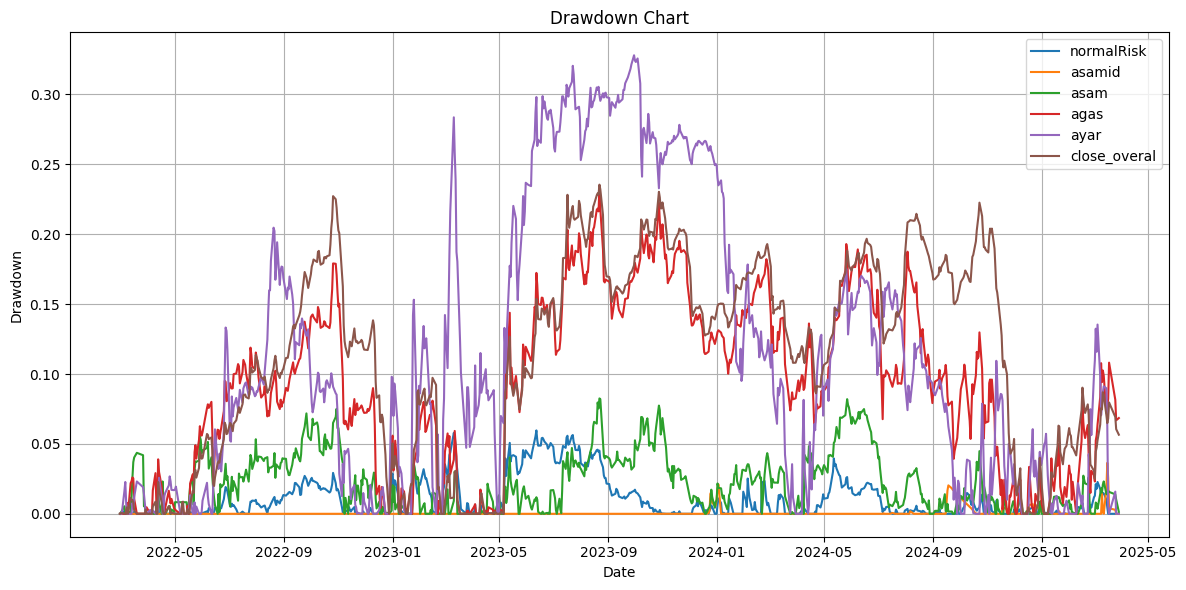

In [20]:
# Plot Drawdown
plt.figure(figsize=(12, 6))
columns = ['normalRisk','asamid', 'asam', 'agas', 'ayar', 'close_overal']
for col in columns:
    plt.plot(drawdowns.index, drawdowns[col], label=col)
plt.title('Drawdown Chart')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("DD_normalRisk")
plt.show()

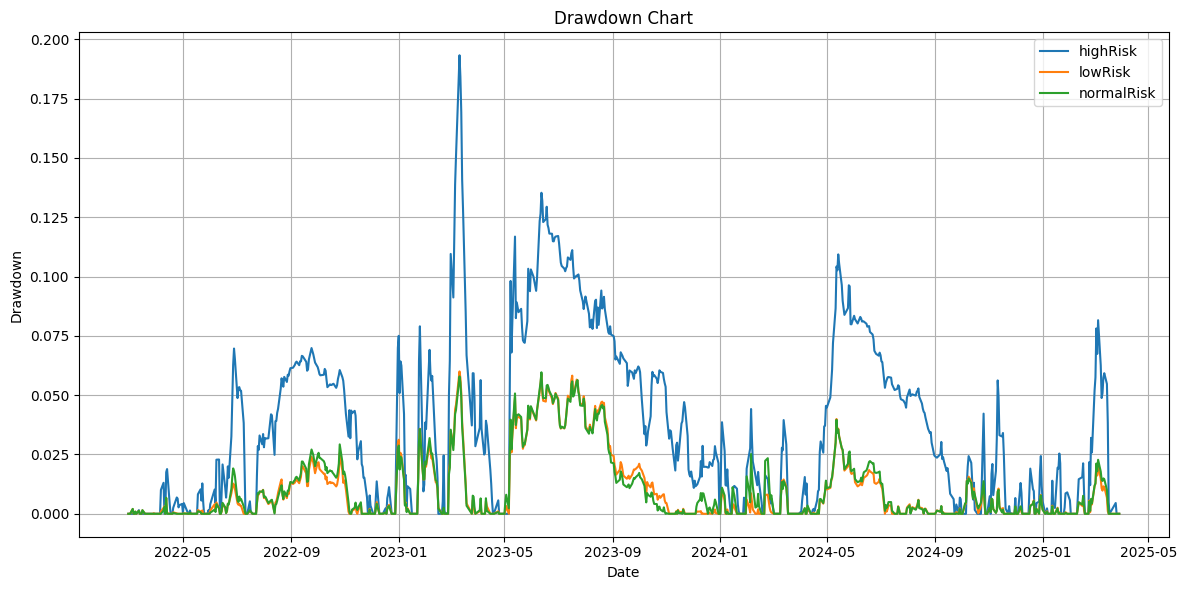

In [21]:
# Plot Drawdown
plt.figure(figsize=(12, 6))
columns = ['highRisk', 'lowRisk', 'normalRisk']
for col in columns:
    plt.plot(drawdowns.index, drawdowns[col], label=col)
plt.title('Drawdown Chart')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("DD_portfolioS")
plt.show()

In [22]:
returns

,highRisk,lowRisk,normalRisk,asamid,asam,agas,ayar,close_overal
Date,,,,,,,,
2022-02-28,0.001993,0.005047,0.005375,0.000634,0.001664,0.004611,0.003912,0.001988
2022-03-02,0.002000,0.001854,0.001771,0.000985,-0.001937,0.000710,0.008937,-0.000541
2022-03-05,0.000488,-0.002000,-0.002074,0.001686,-0.003451,0.016129,-0.016407,0.013695
2022-03-06,0.002692,0.004556,0.004451,0.000562,0.004297,0.034779,-0.006612,0.018156
2022-03-07,0.004764,0.005964,0.005857,0.000561,0.004796,0.016555,0.015316,0.015238
...,...,...,...,...,...,...,...,...
2025-03-17,0.034195,0.010471,0.012032,0.011039,-0.002757,-0.005771,0.058614,-0.003482
2025-03-18,0.040219,0.013166,0.012650,0.022160,0.000870,-0.028589,0.070726,-0.012468
2025-03-25,-0.004562,0.003153,0.003078,0.001085,0.001797,0.029301,-0.015974,0.011238


In [23]:
from scipy.stats import shapiro

stat1, p1 = shapiro(returns['normalRisk'])
print('Shapiro-Wilk Test (normalRisk):', stat1, p1)

stat2, p2 = shapiro(returns['asamid'])
print('Shapiro-Wilk Test (asamid):', stat2, p2)

stat3, p3 = shapiro(returns['asam'])
print('Shapiro-Wilk Test (asam):', stat3, p3)

stat4, p4 = shapiro(returns['agas'])
print('Shapiro-Wilk Test (agas):', stat4, p4)

stat5, p5 = shapiro(returns['ayar'])
print('Shapiro-Wilk Test (ayar):', stat5, p5)

stat6, p6 = shapiro(returns['close_overal'])
print('Shapiro-Wilk Test (close_overal):', stat6, p6)

stat1, p1 = shapiro(returns['highRisk'])
print('Shapiro-Wilk Test (highRisk):', stat1, p1)

stat2, p2 = shapiro(returns['lowRisk'])
print('Shapiro-Wilk Test (lowRisk):', stat2, p2)

Shapiro-Wilk Test (normalRisk): 0.9094900014410641 2.0461238804945537e-20
Shapiro-Wilk Test (asamid): 0.35823621757871504 1.1395767090109388e-44
Shapiro-Wilk Test (asam): 0.9475508353854625 2.0460570131622177e-15
Shapiro-Wilk Test (agas): 0.9688178011839724 2.3339640779380772e-11
Shapiro-Wilk Test (ayar): 0.949359610879468 4.0406144330827895e-15
Shapiro-Wilk Test (close_overal): 0.9514220466015052 8.964194357484819e-15
Shapiro-Wilk Test (highRisk): 0.8923867156933711 3.675869337471531e-22
Shapiro-Wilk Test (lowRisk): 0.9257478901405544 1.634886095914472e-18


In [24]:
from scipy.stats import levene
# p < 0.05 → variances are different

print("levene(returns['asamid'],  returns['normalRisk'])",levene(returns['asamid'],  returns['normalRisk']))  
print("levene(returns['asam'],  returns['normalRisk'])", levene(returns['asam'],  returns['normalRisk']))  
print("levene(returns['agas'],  returns['normalRisk'])", levene(returns['agas'],  returns['normalRisk']))  
print("levene(returns['ayar'],  returns['normalRisk'])", levene(returns['ayar'],  returns['normalRisk']))  
print("levene(returns['highRisk'],  returns['normalRisk'])", levene(returns['highRisk'],  returns['normalRisk']))  
print("levene(returns['lowRisk'],  returns['normalRisk'])", levene(returns['lowRisk'],  returns['normalRisk']))  
print("levene(returns['highRisk'],  returns['lowRisk'])",levene(returns['highRisk'],  returns['lowRisk']))  

levene(returns['asamid'],  returns['normalRisk']) LeveneResult(statistic=171.66764333969107, pvalue=3.6748039938870584e-37)
levene(returns['asam'],  returns['normalRisk']) LeveneResult(statistic=94.72939164636479, pvalue=9.845653207938824e-22)
levene(returns['agas'],  returns['normalRisk']) LeveneResult(statistic=298.98139654156927, pvalue=4.4369316552825554e-61)
levene(returns['ayar'],  returns['normalRisk']) LeveneResult(statistic=364.3616048892208, pvalue=1.1091714065179911e-72)
levene(returns['highRisk'],  returns['normalRisk']) LeveneResult(statistic=112.507263598154, pvalue=2.2633695195877254e-25)
levene(returns['lowRisk'],  returns['normalRisk']) LeveneResult(statistic=2.852796748874798, pvalue=0.09142894977176365)
levene(returns['highRisk'],  returns['lowRisk']) LeveneResult(statistic=138.5942045224231, pvalue=1.2532733517811571e-30)


In [25]:
from scipy.stats import mannwhitneyu
# Run Mann–Whitney U test (two-sided alternative hypothesis)
u_stat, p_val = mannwhitneyu(
    returns['asamid'], 
    returns['normalRisk'], 
    alternative='two-sided'
)
print("Mann–Whitney U test (Portfolio vs Index):", u_stat, p_val)

Mann–Whitney U test (Portfolio vs Index): 254863.0 0.15030525069639364


In [26]:
from scipy.stats import mannwhitneyu
# Run Mann–Whitney U test (two-sided alternative hypothesis)
u_stat, p_val = mannwhitneyu(
    returns['asam'], 
    returns['normalRisk'], 
    alternative='two-sided'
)
print("Mann–Whitney U test (Portfolio vs Index):", u_stat, p_val)

Mann–Whitney U test (Portfolio vs Index): 253722.0 0.11408285069161367


In [27]:
from scipy.stats import mannwhitneyu
# Run Mann–Whitney U test (two-sided alternative hypothesis)
u_stat, p_val = mannwhitneyu(
    returns['agas'], 
    returns['normalRisk'], 
    alternative='two-sided'
)
print("Mann–Whitney U test (Portfolio vs Index):", u_stat, p_val)

Mann–Whitney U test (Portfolio vs Index): 250150.0 0.04301503498630871


In [28]:
from scipy.stats import mannwhitneyu
# Run Mann–Whitney U test (two-sided alternative hypothesis)
u_stat, p_val = mannwhitneyu(
    returns['ayar'], 
    returns['normalRisk'], 
    alternative='two-sided'
)
print("Mann–Whitney U test (Portfolio vs Index):", u_stat, p_val)

Mann–Whitney U test (Portfolio vs Index): 271328.0 0.5448229442997092


In [29]:
from scipy.stats import mannwhitneyu
# Run Mann–Whitney U test (two-sided alternative hypothesis)
u_stat, p_val = mannwhitneyu(
    returns['close_overal'], 
    returns['normalRisk'], 
    alternative='two-sided'
)
print("Mann–Whitney U test (Portfolio vs Index):", u_stat, p_val)

Mann–Whitney U test (Portfolio vs Index): 245360.0 0.008838542194213643


In [30]:
from scipy.stats import mannwhitneyu
# Run Mann–Whitney U test (two-sided alternative hypothesis)
u_stat, p_val = mannwhitneyu(
    returns['highRisk'], 
    returns['normalRisk'], 
    alternative='two-sided'
)
print("Mann–Whitney U test (Portfolio vs Index):", u_stat, p_val)

Mann–Whitney U test (Portfolio vs Index): 272612.0 0.4443054525538246


In [31]:
from scipy.stats import mannwhitneyu
# Run Mann–Whitney U test (two-sided alternative hypothesis)
u_stat, p_val = mannwhitneyu(
    returns['lowRisk'], 
    returns['highRisk'], 
    alternative='two-sided'
)
print("Mann–Whitney U test (Portfolio vs Index):", u_stat, p_val)

Mann–Whitney U test (Portfolio vs Index): 258627.0 0.33147145918533427


In [32]:
from scipy.stats import mannwhitneyu
# Run Mann–Whitney U test (two-sided alternative hypothesis)
u_stat, p_val = mannwhitneyu(
    returns['lowRisk'], 
    returns['normalRisk'], 
    alternative='two-sided'
)
print("Mann–Whitney U test (Portfolio vs Index):", u_stat, p_val)

Mann–Whitney U test (Portfolio vs Index): 264754.0 0.8332818587126434
